# A single-band model for La$_{2}$CuO$_{4}$

In this tutorial, we will solve an effective one-band model for La$_{2}$CuO$_{4}$ derived from first-principles within DMFT. Starting from a DFT calculation, we downfolded the full band structure to a minimal correlated subspace using Wannier functions (see [Tutorial 00](00s-dft.ipynb). We include strong local correlations beyond DFT within the single-site dynamical mean-field theory (DMFT) approximation and solve the resulting interacting model self-consistently. While single-site DMFT does not capture all features of cuprate physics (e.g., momentum-dependent self-energies or pseudogap behavior), it provides a foundational framework to understand spectral weight transfer, quasiparticle renormalization, and Mott physics in a realistic setting.

Specifically, you will learn how to:

- Construct and solve the DMFT equations using TRIQS/ModEST
- Analytically continue Matsubara Green's functions and self-energies
- Post-process and interpret spectral functions and self-energies

## 🧠 1. DMFT loop from scratch

We'll build a single-site DMFT loop for La$_{2}$CuO$_{4}$ using TRIQS/ModEST. We'll proceed in stages, and **your final task will be to write the DMFT self-consistency loop.**

### 🧪 Exercise 1: Load one-body elements
We'll start by loading the target electron density and one-body elements (or obe for short) from the HDF5 file we produced in step 2. Load the ``triqs_modest`` module and use the function ``one_body_elements_from_dft_converter``.

> 💡**Tip**: if you want to see the function signature without leaving the notebook to search the API, you can write
> 
> ```
> ?name_of_function
> ```
> 
> This will produce for you a Docstring for the ``name_of_function``

In [1]:
import triqs_modest as modest
?modest.one_body_elements_from_dft_converter

Docstring:
Dispatched C++ function
[1]  (filename: str,
      threshold: float = 1e-05,
      diagonalize_hloc: bool = False)
    -> tuple[float, OneBodyElementsOnGrid]

   Parameters
   ----------
   
   filename:
      Hdf5 file from dft_tools converter.
   threshold:
      Off-diagonal threshold for discovery of symmetries.
   diagonalize_hloc:
      Diagonalize the local non-interacting hamiltonian.
   verbosity:
      Log steps of creating the one-body elements.
   
   Returns
   -------
   
      The total electron density and a one-body elements.
Type:      builtin_function_or_method

In [2]:
hdf5_filename = 'data/mlwf/lco_wannier.h5'
target_density, obe = modest.one_body_elements_from_dft_converter(hdf5_filename)
print(obe)

One body elements representing a downfolding from (restricted) Bloch 𝓑 to Correlated space 𝓒 from DFT code [one_body_elements_on_grid]
  H:
    Band dispersion ε^σ(k) on a grid [band_dispersion]:
      Number of bands (max): 1
      Represented on a fixed grid of 343 points.
      Shape of H[k_idx, σ, ν, ν'] = [343, 1, 1, 1]
  C_space:
    Local space [orbital_set]:
      Total dimension [M]: 1
      Number of correlated atoms: 1
      Number of inequivalent correlated atoms = 1
      Atomic decomposition:
         dim_a:   1
             a:   0
        irreps: [1]
  P:
    Downfolding projector P^σ_mν(k) on a grid [downfolding_projector]:
      Shape of P[k_idx, σ, m, ν]  = [343, 1, 1, 1]
  IBZ = false



#### 🔎 Explanation of the OBE

We are studying La$_{2}$CuO$_{4}$ approximated as a single-band system meaning that the low-energy degrees of freedom have been reduced to a single correlated Wannier orbital, the Cu-$d_{x^{2}-y^{2}}$ orbital.

The one-body elements (OBE) class contains four pieces:

##### 🔹 H: Band dispersion $\varepsilon^{\sigma}(k)$
This is the non-interacting (Kohn-Sham) Hamiltonian in Bloch space. $\varepsilon^{\sigma}(k)$ is the **band energy** for spin ($\sigma$) at $k$.

##### 🔹 C_space: Local (correlated) orbital space
This describes the **correlated subspace** $\mathcal{C}$ -- the one that will be used in the DMFT impurity model. It appropriately reflects that we are studying: 1 correlated atom with a single-correlated orbital.

##### 🔹 P: the downfolding projector
For our case, the downfolding projector is a trivial identiy matrix. However, when working with different DFT codes or performing a charge self-consistent DFT+DMFT calculation, the projectors become $k$-dependent.

##### 🔹 IBZ: irreducible Brillouin zone symmetrizer
This indicates that the grid of $k$-points spans the **full Brillouin zone**, not just the irreducible wedge (which requires additional symmetry operations to reconstruct the full observable when performing $k$-summations).

### 🧪 Exercise 2: Embedding Description
Create an embedding description from the local space defined in ``obe.C_space``. A central object in TRIQS/ModEST is the ``Embedding`` class, which describes how to map impurity self-energies back to be embedded back to the lattice. For our simple problem, this is trivial, but for more complicated embedding scenarios this can become quite involved (see tutorial ``04-dp-model``). To create an embedding, you can use the function ``make_embedding_with_equivalences``.

In [3]:
E = modest.make_embedding_with_equivalences(obe.C_space)
print(E)

Embedding:
  Spin index (σ/τ) names: ["up", "down"]

  Σ_embed block decomposition:
    dim_α:   1
        α:   0

  Impurities
    Block dimensions, dim_γ for all γ:
      [n_imp = 0] dim_γ =   1
                      γ =   0
    Gf Block structures for solvers as names, [dim]:
      [imp_idx = 0] up_0 [1], down_0 [1]

  Mapping ψ(α,σ) = (imp_idx, γ, τ) 
             |          σ = 0 / up                    σ = 1 / down           
      -------+-------------------------------+------------------------------+
      α = 0  |   (imp_idx = 0, γ = 0, τ = 0)    (imp_idx = 0, γ = 0, τ = 1)  



#### 🔎 Explanation of Embedding

In DMFT, the **embedding** tells you how the _correlated subspace_ (from the DFT/Wannier model) is mapped to one or more **impurity problems**. Thus, it is essential to be able to flexibly construct impurity model(s) for your correlated subspace and ensure the correct assignment of local orbitals and spin channesls. Below is a detailed breakdown of the printout from the ``Embedding`` object.

##### 🔹 spin index ($\sigma/\tau$) names: ["up", "down"]
These are the names of the block-diagonal spin indices $\sigma$ in the lattice model. They correspond to the spin-up and spin-down electrons and will be used to construct the fermionic creation and annihilation operators for the impurity model.

We distinguish between:

- $\sigma$: the spin index in the **embedded lattice problem**, and
- $\tau$: the internal spin index used by the **impurity solver** (e.g., in the impurity solver Green's function blocks).

This distinction allows us to support more generic embeddings.

##### 🔹  $\Sigma$_embed block decomposition
This section describes the **block structure** of the embedded self-energy $\Sigma_{\text{embed}}^{\sigma}(\omega)$. In our case, 

- ``dim_α = 1``: There is only **one embedding block** (denoted by index $\alpha= 0$) corresponding to one correlated orbital.
- This is a **single-orbital** DMFT problem, so the self-energy is scalar valued for each spin.

##### 🔹  Impurities
This describes the structure of the **impurity problems** constructed from the local space:

- ``n_imp = 0``: There is one impurity solver (index 0).
- For this impurity solver: there is one correlated orbital with dimension 1 (``dim_γ``).
- The impurity Green's function will therefore have **two blocks**: one for spin-up and one for spin-down.

The solver's block structure (``gf_struct``) is printed:
```
[imp_idx = 0] up_0 [1], down_0 [1]
```
This means:
- The impurity solver has **two blocks**, one for each spin, and
- Each block is of dimension 1.

##### 🔹 Mapping ψ(α,σ) = (imp_idx, γ, τ) 
This table gives the **mappping from the embedded indices** ``(α,σ)`` to the **impurity solver indices** ``(imp_idx, γ, τ)``.

This means:
- The single correlated orbital in the system is mapped to impurity problem 0.
- The spin-up block maps to the spin-up block of the impurity solver.
- The spin-down block maps to the spin-down block of the impurity solver.

### 🧪 Exercise 3: Chemical Potential and Local Green's function
Let's use a root finder scheme to find the chemical potential and subsequently compute the local non-interacting Green's function. You will use the functions ``find_chemical_potential`` and ``gloc``.

In order to complete this exercise, you will need to define a mesh. We will work at finite-temparature in the imaginary time formalism, so we will compute the local Green's function on the Matsubara axis with inverse temperature $\beta$ = 10 1/eV.

In [4]:
from triqs.gf import MeshImFreq

beta = 10.0 # inverse temperature
mesh = MeshImFreq(beta, S='Fermion', n_iw=251) # Matsubara mesh

# Step 1: find the chemical potential for target density
mu = modest.find_chemical_potential(target_density, obe, beta, verbosity=True) # verbosity broken!

# Step 2: use this chemical potential to compute the local Green's function.
gloc_C = modest.gloc(mesh, obe, mu)
print(gloc_C)

Green's Function  composed of 2 2-index blocks: 
 Greens Function ('0', 'up') with mesh Imaginary Freq Mesh with beta = 10, statistic = Fermion, n_iw = 251, positive_only = false and target_shape (1, 1): 
 
 Greens Function ('0', 'down') with mesh Imaginary Freq Mesh with beta = 10, statistic = Fermion, n_iw = 251, positive_only = false and target_shape (1, 1): 
 



### 🧪 Exercise 4: Extract the Local Green's function for the impurity solver(s)
The function ``gloc`` returns the local Green's function in the full correlated subspace. In general, this object is of dimension $ M\times M$. To connect to the impurity solver, we would like to view this Green's function in the space of impurity model(s). This is where the ``Embedding`` class comes in. The class contains two methods: ``extract`` and ``embed``.

- ``extract``: maps a Green's function (or array) from the full correlated space to the space of each impurity solver.
- ``embed``: (reverse of extract) maps a list of Green's functions (or arrays) and embeds these impurities into the bigger correlated space according to the mapping described in the ``Embedding``.

Thus, to prepare the Green's function for the impurity solver, we will use the ``extract`` method from the ``Embedding`` class. In general, the extract function will return a list of objects where the length corresponds to the number of impurity problems defined in the embedding description. Because we are working with a single impurity, we will simply grab the first element from this list everytime this function is called.

> 💡 **Note**: for a more complicated multi-site, multi-orbital DMFT problem, it is often convenient to loop over these lists.

In [5]:
Gloc = E.extract(gloc_C)[0]
print(Gloc)

Green Function G composed of 2 blocks: 
 Greens Function G_up_0 with mesh Imaginary Freq Mesh with beta = 10, statistic = Fermion, n_iw = 251, positive_only = false and target_shape (1, 1): 
 
 Greens Function G_down_0 with mesh Imaginary Freq Mesh with beta = 10, statistic = Fermion, n_iw = 251, positive_only = false and target_shape (1, 1): 
 



### 🧪 Exercise 5: Impurity Levels and Hybridization function

The central inputs to the impurity solver are the impurity levels ($\varepsilon_{d}$) and the hybridization function ($\Delta(i\omega_{n})$). In this excercise, you will calculate the impurity levels and the hybridization function. The impurity levels correspond to:

$$ [\varepsilon_{d}]_{m m'} = \sum_{k} P_{m\nu}(k) (H_{\nu\nu'}(k)-\mu) P^{\dagger}_{m'\nu'},$$
where $\mu$ is the chemical potential. We can compute the impurity levels with the function ``impurity_levels`` which takes as an argument the ``obe``.

> 💡 **Tip**: The function ``impurity_levels`` returns the local impurity levels in the full correlated space. In a similar fashion to the local Green's function, you can use ``Embedding``'s ``extract`` function to obtain the impurity levels for each impurity problem.

The hybridization function is defined as:

$$ \Delta(\omega) = \omega - \varepsilon_{d} - \mathcal{G}_{0}^{-1}(\omega), $$

where $\mathcal{G}_{0} = ((G_{\text{loc}})^{-1} + \Sigma)^{-1}$. The hybridization function can be computed using the function ``extract_delta``.

In [6]:
# Step 1: impurity levels in the C space
hloc0_C = modest.impurity_levels(obe) - mu

# Step 2: extract the local levels into the impurity space
hloc0 = E.extract(hloc0_C)[0]

# Step 3: compute Δ using mu, hloc0 and Gloc
Delta_iw = modest.extract_delta(hloc0, Gloc)

### 🧪 Exercise 6: Define the interaction
We need to define the interaction Hamiltonian for our impurity model. For our model, this is:

$$ H_{\text{int}} = U n^{\uparrow} n^{\downarrow}.$$

Use the many-body operators within the TRIQS library to write this interaction. Let's take $U$ = 3.6 eV.

> 💡 **Tip**: The many-body operators must match between all of your Green's functions. You can always get the operator names from the member ``imp_block_shapes`` from the ``Embedding`` class. For our example, the fundamental operators are ``c('up_0',0)`` and ``c('down_0', 0)``.

In [7]:
from triqs.operators import n
from utils.solvers import solve

U = 3.6
h_int = U*n('up_0',0)*n('down_0',0)

Starting serial run at: 2025-07-31 15:02:00.213375


### ▶️ Run the CT-HYB impurity solver

In [8]:
solver_params = dict(length_cycle=80, n_cycles = int(5e+5), 
                          n_warmup_cycles = int(1e+3),
                          perform_tail_fit=True, fit_min_w=6, fit_max_w=10,
                          imag_threshold = 1e-6)
results = solve(Delta_iw, hloc0, h_int, **solver_params)

Root finder search of Chemical Potential to obtain Total Density = 1 +/- 1e-05
x=0.5, f(x)= 5.25856294431212e-47
x=1, f(x)= 7.804399389051097e-45
x=1.5, f(x)= 1.1582755682272908e-42
x=2, f(x)= 1.7190333619194357e-40
x=2.5, f(x)= 2.5512717184518787e-38
x=3, f(x)= 3.7864229546450085e-36
x=3.5, f(x)= 5.619549923973799e-34
x=4, f(x)= 8.340151569515947e-32
x=4.5, f(x)= 1.2377882418261722e-29
x=5, f(x)= 1.837040632694462e-27
x=5.5, f(x)= 2.726410036979813e-25
x=6, f(x)= 4.046351265971475e-23
x=6.5, f(x)= 6.0053177422153494e-21
x=7, f(x)= 8.912681775369343e-19
x=7.5, f(x)= 1.3227592583585248e-16
x=8, f(x)= 1.963148802650765e-14
x=8.5, f(x)= 2.9135711556949514e-12
x=9, f(x)= 4.3241229500523946e-10
x=9.5, f(x)= 6.417557602297381e-08
x=10, f(x)= 9.522326167591098e-06
x=10.5, f(x)= 0.001366948154980121
x=11, f(x)= 0.03569944709537811
x=11.5, f(x)= 0.1374472842572524
x=12, f(x)= 0.3240255107869281
x=12.5, f(x)= 0.6164106608742425
x=13, f(x)= 1.2109291198954333
0 < Chemical Potential < 13
3.5431918

410129966e-49 < Total Density < 1.2109291198954333
10.735558164727744 < Chemical Potential < 13
0.010970122668893021 < Total Density < 1.2109291198954333
12.601955796429431 < Chemical Potential < 13
0.7467574408833251 < Total Density < 1.2109291198954333
12.601955796429431 < Chemical Potential < 12.81912055962288
0.7467574408833251 < Total Density < 1.0241705368126055
12.601955796429431 < Chemical Potential < 12.800199358784884
0.7467574408833251 < Total Density < 1.0032919012441288
12.601955796429431 < Chemical Potential < 12.79765545794349
0.7467574408833251 < Total Density < 1.0004520461012543
12.601955796429431 < Chemical Potential < 12.797306750217016
0.7467574408833251 < Total Density < 1.0000620905368693
12.601955796429431 < Chemical Potential < 12.797258865404736
0.7467574408833251 < Total Density < 1.0000085285552072
Chemical Potential found in 7 iterations:
Total Density = 1.0000085285552072; Chemical Potential = 12.797258865404736

╔╦╗╦═╗╦╔═╗ ╔═╗  ���─┐┌┬┐┬ ┬┬ ┬┌┐ 
 ║ ╠╦╝║║═

 ETA 00:00:13 cycle 375157 of 500000
15:02:54  97% ETA 00:00:01 cycle 487660 of 500000
15:02:55 100% ETA 00:00:00 cycle 499999 of 500000


[Rank 0] Collect results: Waiting for all mpi-threads to finish accumulating...
[Rank 0] Timings for all measures:
Measure                                    | seconds   
Auto-correlation time                      | 0.0767769 
Average order                              | 0.0126945 
Average sign                               | 0.0141851 
Density Matrix for local static observable | 0.661941  
G_tau measure                              | 0.123057  
Total measure time                         | 0.888655  
[Rank 0] Acceptance rate for all moves:
Move set Insert two operators: 0.145515
  Move  Insert Delta_up_0: 0.145519
  Move  Insert Delta_down_0: 0.145511
Move set Remove two operators: 0.145427
  Move  Remove Delta_up_0: 0.145347
  Move  Remove Delta_down_0: 0.145507
Move set Insert four operators: 0.0290941
  Move  Insert Delta_up_0_up_0: 0.0323993
  

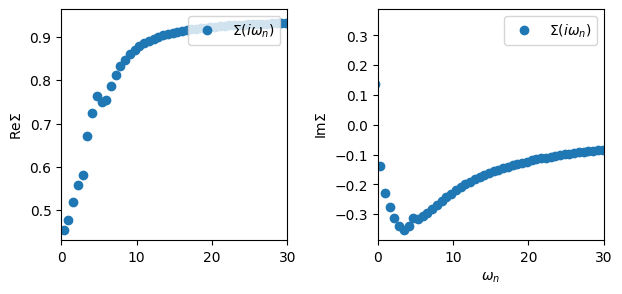

In [9]:
from triqs.plot.mpl_interface import oplot, plt

fig, ax = plt.subplots(1,2, sharex=True, figsize=(7,3))
ax[0].oplot(results.Sigma_iw['up_0'].real, 'o', label=r'$\Sigma(i\omega_{n})$'); 
ax[0].set_ylabel(r'Re$\Sigma$'); ax[0].set_xlabel('')
ax[1].oplot(results.Sigma_iw['up_0'].imag, 'o', label=r'$\Sigma(i\omega_{n})$'); 
ax[1].set_ylabel(r'Im$\Sigma$')
ax[0].set_xlim(0, 30)
plt.subplots_adjust(wspace=0.4)
plt.show()

### 🧪 Exercise 7: Write the DMFT loop

You now have all of the pieces to write the DMFT self-consistencey loop. Your task is to fill in the steps that occur during each DMFT iteration, such as solving the impurity problem, updating the self-energy, chemical potential, Green's function, and hybridization function.

#### 🧩 Your Task
Fill in the provided pseudocode to perform the following steps for each DMFT iteration:
1. Solve the impurity problem
2. Embed the self-energy
3. Update the chemical potential
4. Compute the local Green's function
5. Update the hybridization function

In [10]:
n_dmft_loops = 10
delta_n=[]

for n_iter in range(n_dmft_loops):
    print(f"DMFT iteration= {n_iter}")
    
    # solve!
    solver_results = solve(Delta_iw, hloc0, h_int, **solver_params)
    
    # update Sigma!
    Sigma_dynamic_C  = E.embed([ solver_results.Sigma_dynamic ])
    Sigma_hartree_C  = E.embed([ solver_results.Sigma_Hartree ])

    # update mu!
    mu     = modest.find_chemical_potential(target_density, obe, Sigma_dynamic_C, Sigma_hartree_C, verbosity=False)
    
    # update Gloc!
    Gloc = E.extract(modest.gloc(obe, mu, Sigma_dynamic_C, Sigma_hartree_C))[0]

    # update hloc0 with μ!
    hloc0 = E.extract(modest.impurity_levels(obe) - mu)[0]
    
    # update Δ!
    Delta_iw = modest.extract_delta(hloc0, Gloc, solver_results.Sigma_dynamic, solver_results.Sigma_Hartree)
    
    delta_n.append(abs(Gloc.total_density()-solver_results.G_iw.total_density()))
    print(f"Δn = |n_lattice - n_impurity| = {delta_n[-1]}")

DMFT iteration= 0

╔╦╗╦═╗╦╔═╗ ╔═╗  ┌─┐┌┬┐┬ ┬┬ ┬┌┐ 
 ║ ╠╦╝║║═╬╗╚═╗  │   │ ├─┤└┬┘├┴┐
 ╩ ╩╚═╩╚═╝╚╚═╝  └─┘ ┴ ┴ ┴ ┴ └─┘

The local Hamiltonian of the problem:
0.0983631*c_dag('down_0',0)*c('down_0',0) + 0.0983631*c_dag('up_0',0)*c('up_0',0) + 3.6*c_dag('down_0',0)*c_dag('up_0',0)*c('up_0',0)*c('down_0',0)
Using autopartition algorithm to partition the local Hilbert space
Found 4 subspaces.

Warming up ...
15:02:56  95% ETA 00:00:00 cycle 949 of 1000
15:02:56 100% ETA 00:00:00 cycle 999 of 1000



Accumulating ...
15:02:56   0% ETA 00:01:00 cycle 824 of 500000
15:02:58   3% ETA 00:00:51 cycle 19825 of 500000
15:03:00   8% ETA 00:00:49 cycle 43108 of 500000
15:03:03  14% ETA 00:00:45 cycle 73897 of 500000
15:03:07  22% ETA 00:00:40 cycle 111649 of 500000
15:03:12  31% ETA 00:00:36 cycle 157340 of 500000
15:03:18  42% ETA 00:00:30 cycle 214931 of 500000
15:03:26  57% ETA 00:00:22 cycle 287256 of 500000
15:03:36  75% ETA 00:00:13 cycle 376180 of 500000
15:04:34  90% ETA 00:00:09 cycle 454700 of

Execution time: 0.098073 seconds


Δn = |n_lattice - n_impurity| = 0.4790725195770793
DMFT iteration= 1

╔╦╗╦═╗╦╔═╗ ╔═╗  ┌─┐┌┬┐┬ ┬┬ ┬┌┐ 
 ║ ╠╦╝║║═╬╗╚═╗  │   │ ├─┤└┬┘├┴┐
 ╩ ╩╚═╩╚═╝╚╚═╝  └─┘ ┴ ┴ ┴ ┴ └─┘

The local Hamiltonian of the problem:
-0.473337*c_dag('down_0',0)*c('down_0',0) + -0.473337*c_dag('up_0',0)*c('up_0',0) + 3.6*c_dag('down_0',0)*c_dag('up_0',0)*c('up_0',0)*c('down_0',0)
Using autopartition algorithm to partition the local Hilbert space
Found 4 subspaces.

Warming up ...
15:04:54  66% ETA 00:00:00 cycle 667 of 1000
15:04:54 100% ETA 00:00:00 cycle 999 of 1000



Accumulating ...
15:04:54   0% ETA 00:01:16 cycle 656 of 500000
15:04:56   2% ETA 00:01:18 cycle 13323 of 500000
15:05:07   5% ETA 00:03:32 cycle 29241 of 500000
15:05:13  14% ETA 00:01:48 cycle 72941 of 500000
15:05:19  26% ETA 00:01:08 cycle 134047 of 500000
15:06:31  31% ETA 00:03:31 cycle 157730 of 500000
15:22:36  51% ETA 00:16:42 cycle 257225 of 500000
15:23:12 100% ETA 00:00:00 cycle 499999 of 500000


[Rank 0] Collect results: Waiting for a

Execution time: 0.152873 seconds
Execution time: 0.149489 seconds



╔╦╗╦═╗╦╔═╗ ╔═╗  ┌─┐┌┬┐┬ ┬┬ ┬┌┐ 
 ║ ╠╦╝║║═╬╗╚═╗  │   │ ├─┤└┬┘├┴┐
 ╩ ╩╚═╩╚═╝╚╚═╝  └─┘ ┴ ┴ ┴ ┴ └─┘

The local Hamiltonian of the problem:
-1.1156*c_dag('down_0',0)*c('down_0',0) + -1.1156*c_dag('up_0',0)*c('up_0',0) + 3.6*c_dag('down_0',0)*c_dag('up_0',0)*c('up_0',0)*c('down_0',0)
Using autopartition algorithm to partition the local Hilbert space
Found 4 subspaces.

Warming up ...
15:37:39 100% ETA 00:00:00 cycle 999 of 1000



Accumulating ...
15:37:40   0% ETA 00:00:45 cycle 1103 of 500000
15:37:42   4% ETA 00:00:41 cycle 24230 of 500000
15:37:44  10% ETA 00:00:37 cycle 54597 of 500000
15:37:47  18% ETA 00:00:34 cycle 91322 of 500000
15:37:51  27% ETA 00:00:31 cycle 137385 of 500000
15:37:56  38% ETA 00:00:26 cycle 192317 of 500000
15:38:02  51% ETA 00:00:21 cycle 259597 of 500000
15:38:10  69% ETA 00:00:13 cycle 347251 of 500000
15:38:20  90% ETA 00:00:04 cycle 454098 of 500000
15:38:24 100% ETA 00:00:00 cycle 499999 of 500000


[Rank 0] Collect results: Waiting for all mpi-threads to

...

Execution time: 0.129596 seconds
Execution time: 0.151278 seconds
Insert error : recovering ... 



  Move  Insert Delta_up_0_down_0: 0.0344073
  Move  Insert Delta_down_0_up_0: 0.0343278
  Move  Insert Delta_down_0_down_0: 0.022858
Move set Remove four operators: 0.0287263
  Move  Remove Delta_up_0_up_0: 0.0229342
  Move  Remove Delta_up_0_down_0: 0.0345052
  Move  Remove Delta_down_0_up_0: 0.0345747
  Move  Remove Delta_down_0_down_0: 0.0228836
Move  Shift one operator: 0.295872
[Rank 0] Warmup lasted: 0.0772596 seconds [00:00:00]
[Rank 0] Simulation lasted: 38.3075 seconds [00:00:38]
[Rank 0] Number of measures: 500000
Total number of measures: 500000
Average sign: 1
Average order: 3.50181
Auto-correlation time: 1.08869
Δn = |n_lattice - n_impurity| = 0.026200680534560483
DMFT iteration= 7

╔╦╗╦═╗╦╔═╗ ╔═╗  ┌─┐┌┬┐┬ ┬┬ ┬┌┐ 
 ║ ╠╦╝║║═╬╗╚═╗  │   │ ├─┤└┬┘├┴┐
 ╩ ╩╚═╩╚═╝╚╚═╝  └─┘ ┴ ┴ ┴ ┴ └─┘

The local Hamiltonian of the problem:
-1.56452*c_dag('down_0',0)*c('down_0',0) + -1.56452*c_dag('up_0',0)*c('up_0',0) + 3.6*c_dag('down_0',0)*c_dag('up_0',0)*c('up_0',0)*c('down_0',0)
Using autopar

Execution time: 0.189605 seconds


Δn = |n_lattice - n_impurity| = 0.02194850155860495lation time: 1.28774

DMFT iteration= 8

╔╦╗╦═╗╦╔═╗ ╔═╗  ┌─┐┌┬┐┬ ┬┬ ┬┌┐ 
 ║ ╠╦╝║║═╬╗╚═╗  │   │ ├─┤└┬┘├┴┐
 ╩ ╩╚═╩╚═╝╚╚═╝  └─┘ ┴ ┴ ┴ ┴ └─┘

The local Hamiltonian of the problem:
-1.61513*c_dag('down_0',0)*c('down_0',0) + -1.61513*c_dag('up_0',0)*c('up_0',0) + 3.6*c_dag('down_0',0)*c_dag('up_0',0)*c('up_0',0)*c('down_0',0)
Using autopartition algorithm to partition the local Hilbert space
Found 4 subspaces.
Δn = |n_lattice - n_impurity| = 0.020396041056038428
DMFT iteration= 9

Warming up ...
15:41:52 100% ETA 00:00:00 cycle 999 of 1000



Accumulating ...
15:41:53   0% ETA 00:00:37 cycle 1319 of 500000
15:41:55   5% ETA 00:00:35 cycle 28031 of 500000
15:41:57  12% ETA 00:00:31 cycle 64361 of 500000
15:42:00  21% ETA 00:00:28 cycle 107527 of 500000
15:42:04  32% ETA 00:00:24 cycle 161894 of 500000
15:42:09  46% ETA 00:00:19 cycle 230314 of 500000
15:42:15  63% ETA 00:00:13 cycle 315416 of 500000
15:42:23  84% ETA 00:00:05 cycle 421767 of 

Execution time: 0.161016 seconds
Insert error : recovering ... 
Execution time: 0.186775 seconds


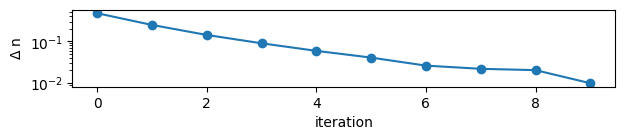

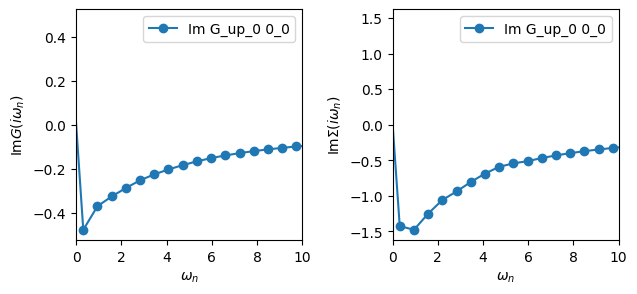

In [18]:
fig, ax = plt.subplots(figsize=(7,1))
ax.semilogy(delta_n, 'o-')
ax.set_xlabel('iteration'); ax.set_ylabel(r'$\Delta$ n')

fig, ax = plt.subplots(1,2,sharex=True, figsize=(7,3))
ax[0].oplot(solver_results.G_iw['up_0'].imag, 'o-'); ax[0].set_ylabel(r'Im$G(i\omega_{n})$')
ax[1].oplot(solver_results.Sigma_iw['up_0'].imag, 'o-'); ax[1].set_ylabel(r'Im$\Sigma(i\omega_{n})$')
ax[0].set_xlim(0, 10);
plt.subplots_adjust(wspace=0.4)
plt.show()

### 🧪 Exercise 8: Estimate Z from the Matsubara self-energy

Using the self-energy that you obtained above, estimate the quasiparticle renormalization factor and the scattering rate, which are defined as 

$$ Z = (1 - \partial_{\omega_{n}}\text{Im}\Sigma(i\omega_{n}) |_{\omega_{n}\rightarrow 0})^{-1}.$$

We can estimate this quantity a couple of different ways. The simplest is to just look at the first Matsubara point,

$$ Z \sim \Big (1 - \frac{\mathrm{Im}\Sigma(i\omega_{0})}{\omega_{0}} \Big )^{-1},$$
where $\omega_{0} = \frac{\pi}{\beta}$.

In [19]:
import numpy as np

Z = 1/(1 - solver_results.Sigma_iw['up_0'][0,0](0).imag * beta / np.pi)
print(f'Z= {Z}')

Z= 0.18077631697794225


## 🌀 2. Analytic continuation: from Matsubara to real frequencies

In this section, we will learn how to **analytically continue** our results from Matsubara (imaginary) frequencies onto the real-frequency axis, so that we may plot spectral functions. Because analytic continuation is an ill-posed problem, it is notoriously unstable, and the method itself remains an active area of research. However, there are two common analytic continuation techniques: Padé analytic continuation and the maximum entropy (MaxEnt) method. In this section, we will use Padé analytic contintuation since it is simpler. There is an additional tutorial using the MaxEnt method to continue the data.

### ❓The problem
We assume the Matsubra Green's function $G(i\omega_{n})$ corresponds to a dynamic correlation function $G(\omega)$ where $\omega_{n}$ is the Matsubara frequency and $\omega$ is the real frequency. The function $G(z)$ is analytic in the whole upper complex plane of $z$ excluding the real axis, the retarded Green function can be obtained by analytic contintuation $$G(\omega) = G(i\omega_{n}\rightarrow \omega + i0^{+})$$. The spectral function $A(\omega)$ is determined by taking the imaginary part of $G(\omega + i0^{+})$ by the formula

$$ A(\omega) = -\frac{1}{\pi}\mathrm{Im}G(\omega + i0^{+})$$

### 📐 Padé method
Padé analytic continuation is based on the assumption that the Matsubara Green function can be approximated by a rational function of degree $r$

$$ G(z) = \frac{\sum_{i=0}^{r-1} p_{i}z^{i}}{\sum_{j=0}^{r-1}q_{j}z^{j} + z^{r}}, $$
where $p_{i}$ and $q_{j}$ are complex. The coefficients can be determined by solving $2r$ linear equatiions from $2r$ arbitrary but different input points ${i\omega_{n}, G(i\omega_{n})}$. Once the coefficients are determined, we replace $z$ with $\omega + i0^{+}$ to obtain the retarded correlation function.

### 🧪 Exercise 9: Analytically continue the Matsubara Green's function

In this exercise, we will analytically continue the Matsubara Green's function onto the real frequency axis.

#### 🧩 Your task
1. set up a ``BlockGf`` with a real frequency mesh ``MeshReFreq``.
2. For each block in the Matsubara Green's function, use the ``set_from_pade`` method to obtain the real frequency Green's function for each block.
3. Plot the resulting spectral function using the formula $A(\omega) = -\frac{1}{\pi}\text{Im}G(\omega + i0^{+})$.

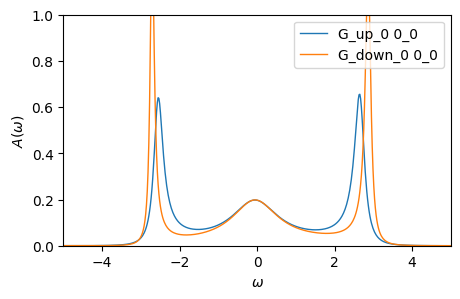

In [20]:
from triqs.gf import BlockGf, MeshReFreq

n_w = 1000
window = (-10, 10)

# Step 1: set up real-frequency mesh and BlockGf

## get the block shape of the Matsubara Green's function
gf_struct = [ (bl, g.target_shape[0]) for bl, g in solver_results.G_iw ]

## setup real-frequency mesh
mesh = MeshReFreq(window, n_w)

## construct Block Green's function on real-frequency mesh
G_w = BlockGf(mesh=mesh, gf_struct=gf_struct)

# Step 2: loop over the blocks and call set_from_pade
n_points = 25
freq_offset = 0.0
for block, g in G_w: 
    g.set_from_pade(solver_results.G_iw[block], n_points=n_points, freq_offset=freq_offset)

# Step 3: plot the spectral function
fig, ax = plt.subplots(figsize=(5,3))
ax.oplot(-1/np.pi*G_w.imag, lw=1)
ax.set_ylabel(r'$A(\omega)$'); ax.set_xlim(-5,5); ax.set_ylim(0, 1)
plt.show()

> ⚠️ **Warning**: The Pade method can be sensitive to the choice of ``n_points``, which correpsonds to the amount of Matsubara data you allow the algorithm to see. Try changing this parameter to see how the resulting spectral function changes.

In [21]:
from utils.maxent import Aw_from_maxent

mesh, Aw = Aw_from_maxent(solver_results.G_iw, omega_min=-10, omega_max=10, alpha_min=1e-6, alpha_max=1e2, n_alpha_points=50, n_omega_points=200, error=0.04)

Calculating diagonal elements.
Calling MaxEnt for element 0 0
2025-07-31 15:43:53.503942
MaxEnt run
TRIQS application maxent
Copyright(C) 2018 Gernot J. Kraberger
Copyright(C) 2018 Simons Foundation
Authors: Gernot J. Kraberger and Manuel Zingl
This program comes with ABSOLUTELY NO WARRANTY.
This is free software, and you are welcome to redistributeit under certain conditions; see file LICENSE.
Please cite this code and the appropriate original papers (see documentation).

Minimal chi2: 0.00012497390845518888
scaling alpha by a factor 1507 (number of data points)
alpha[ 0] =   1.50700000e+05, chi2 =   4.36937643e+03, n_iter=       4 
alpha[ 1] =   1.03477981e+05, chi2 =   4.13296108e+03, n_iter=       3 
alpha[ 2] =   7.10530361e+04, chi2 =   3.80895085e+03, n_iter=       3 
alpha[ 3] =   4.87884852e+04, chi2 =   3.38192545e+03, n_iter=       3 
alpha[ 4] =   3.35005570e+04, chi2 =   2.85408404e+03, n_iter=       4 
alpha[ 5] =   2.30031188e+04, chi2 =   2.26251459e+03, n_iter=       4

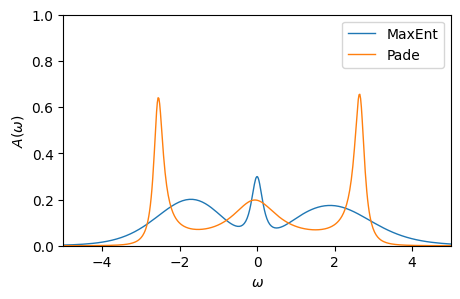

In [22]:
fig, ax = plt.subplots(figsize=(5,3))
ax.plot(mesh, Aw['up_0'].get_A_out('LineFitAnalyzer')[0,0].real, lw=1, label='MaxEnt')
ax.oplot(-1/np.pi*G_w['up_0'].imag, lw=1, label='Pade')
ax.set_ylabel(r'$A(\omega)$'); ax.set_xlim(-5,5); ax.set_ylim(0, 1)
plt.show()

### 🧪 Exercise 10: Understanding your spectral function

Let's take a closer look out the spectral functions that we just obtained. Specifically, let's see if it reproduces the features that we expect, which are spectral weight transfer into the upper and lower Hubbard bands around $\pm U/2$ as well as the width of the quasiparticle peak which goes as $\sim Z \Gamma$, where $\Gamma = -\mathrm{Im}\Sigma(0)$.

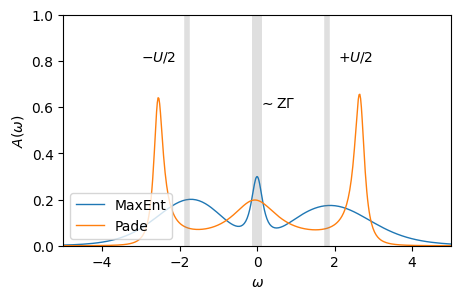

In [23]:
fig, ax = plt.subplots(figsize=(5,3))
ax.plot(mesh, Aw['up_0'].get_A_out('LineFitAnalyzer')[0,0].real, lw=1, label='MaxEnt')
ax.oplot(-1/np.pi*G_w['up_0'].imag, lw=1, label='Pade')
ax.set_ylabel(r'$A(\omega)$'); ax.set_xlim(-5,5); ax.set_ylim(0, 1)
ax.legend(loc='lower left')
# We expect upper and lower Hubbard bands at +/- U/2
ax.axvline(+U/2, color='grey', lw=4, alpha=0.25); ax.axvline(-U/2, color='grey', lw=4, alpha=0.25)
ax.text(-3, 0.8, r'$-U/2$'); ax.text(2.1, 0.8, r'$+U/2$')

# We expect the width of the peak to be Z*ImΣ(0)
Gamma = -solver_results.Sigma_iw['up_0'][0,0](0).imag
ax.axvspan(-0.5*Z*Gamma, 0.5*Z*Gamma, color='grey', lw=0, alpha=0.25); ax.text(0.05, 0.6, r'$\sim$Z$\Gamma$')
plt.show()

### 🧪 Exercise 11: Analytically continue the Matsubara self-energy

In this exercise, we will analytically continue the Matsubara self-energy onto the real-frequency axis. Due to implementation details, you can directly use the same Python code to analytically continue a self-energy in the same way as a Green's function in TRIQS. 

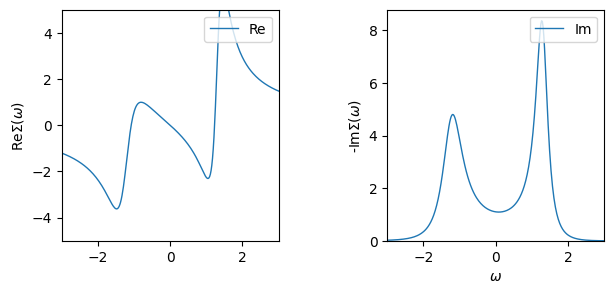

In [24]:
n_w = 1000
window = (-10, 10)

mesh = MeshReFreq(window, n_w)
# Step 1: construct Block Green's function on real-frequency mesh
Sigma_w_pade = BlockGf(mesh=mesh, gf_struct=gf_struct)

# Step 2: loop over the blocks and call set_from_pade
n_points = 25
freq_offset = 0.0
for block, g in Sigma_w_pade: g.set_from_pade(solver_results.Sigma_iw[block], n_points=n_points, freq_offset=freq_offset)

# Step 3: plot the spectral function
fig, ax = plt.subplots(1,2,sharex=True, figsize=(7,3))
ax[0].oplot(Sigma_w_pade['up_0']-Sigma_w_pade['up_0'][0,0](0.0).real, mode='R', lw=1, label='Re')
ax[1].oplot(-Sigma_w_pade['up_0'], mode='I', lw=1, label='Im')
ax[0].set_ylim(-5,5); ax[0].set_xlim(-3,3); ax[1].set_ylim(0, ); 
ax[0].set_xlabel('')
ax[0].set_ylabel(r'Re$\Sigma(\omega)$'); ax[1].set_ylabel(r'-Im$\Sigma(\omega)$')
plt.subplots_adjust(wspace=0.5)
plt.show()

In [31]:
from utils.maxent import Sigma_w_from_maxent

Sigma_w = Sigma_w_from_maxent(solver_results.Sigma_iw)

Calculating diagonal elements.
Calling MaxEnt for element 0 0
2025-07-31 15:55:48.115685
MaxEnt run
TRIQS application maxent
Copyright(C) 2018 Gernot J. Kraberger
Copyright(C) 2018 Simons Foundation
Authors: Gernot J. Kraberger and Manuel Zingl
This program comes with ABSOLUTELY NO WARRANTY.
This is free software, and you are welcome to redistributeit under certain conditions; see file LICENSE.
Please cite this code and the appropriate original papers (see documentation).

Minimal chi2: 0.000393578081332543
scaling alpha by a factor 1507 (number of data points)
alpha[ 0] =   1.50700000e+05, chi2 =   5.01153574e+03, n_iter=       4 
alpha[ 1] =   1.03477981e+05, chi2 =   4.77810169e+03, n_iter=       3 
alpha[ 2] =   7.10530361e+04, chi2 =   4.45742988e+03, n_iter=       3 
alpha[ 3] =   4.87884852e+04, chi2 =   4.03158610e+03, n_iter=       3 
alpha[ 4] =   3.35005570e+04, chi2 =   3.49549364e+03, n_iter=       4 
alpha[ 5] =   2.30031188e+04, chi2 =   2.87238495e+03, n_iter=       4 


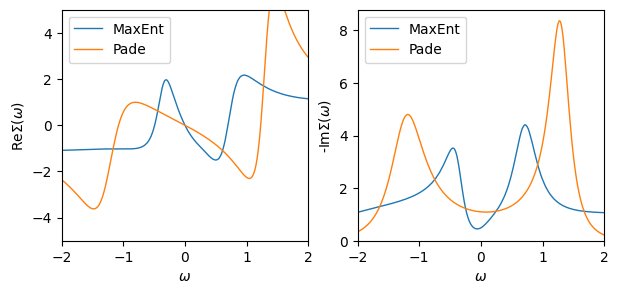

In [38]:
fig, ax = plt.subplots(1,2,sharex=True, figsize=(7,3))
# maxent
ax[0].oplot(Sigma_w['up_0']-Sigma_w['up_0'][0,0](0.0).real, mode='R', lw=1, label='MaxEnt')
ax[1].oplot(-Sigma_w['up_0'], mode='I', lw=1, label='MaxEnt')
# pade
ax[0].oplot(Sigma_w_pade['up_0']-Sigma_w_pade['up_0'][0,0](0.0).real, mode='R', lw=1, label='Pade')
ax[1].oplot(-Sigma_w_pade['up_0'], mode='I', lw=1, label='Pade')
ax[0].legend(loc='upper left'); ax[1].legend(loc='upper left')
ax[0].set_ylim(-5,5); ax[0].set_xlim(-2,2); ax[1].set_ylim(0, ); 
ax[0].set_ylabel(r'Re$\Sigma(\omega)$'); ax[1].set_ylabel(r'-Im$\Sigma(\omega)$')
plt.show()

### 🧪 Exercise 12: Estimate Z and the scattering rate from the self-energy

Using the self-energy that you obtained above, estimate the quasiparticle renormalization factor and the scattering rate, which are defined as 

$$ Z = (1 - \partial_{\omega}\text{Re}\Sigma(\omega) |_{\omega\rightarrow0})^{-1}.$$
The scattering rate $\Gamma$ is proportional to $-\mathrm{Im}\Sigma(\omega=0)$. For $Z$, you can fit a linear line to the low-frequency data in the real part of spectrum and use the slope of the line to estimate the derivate.  For the scattering rate, you can fit a polynomial to the low-frequency data in the imaginary part of the self-energy and estimate $-\text{Im}\Sigma(0)$ from this fit.

In [39]:
x = np.linspace(-0.2, 0.2,10)
y = [Sigma_w['up_0'][0,0](xx).real for xx in x]
dSdw = np.polyfit(x,y,1)[0]
Z = 1/(1 - dSdw)
print(f'     Z  =  {Z}')
print(f'-ImΣ(0) = {Sigma_w['up_0'][0,0](0.0).imag}')

     Z  =  0.15541304562679925
-ImΣ(0) = -0.49110079954506397


## 📊 3. Plotting our results

### 🧪 Exercise 13: Plot the momentum-resolved spectral function along the high-symmetry path in the Brillouin zone

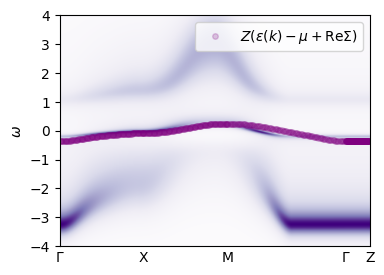

In [60]:
from triqs.lattice.utils import TB_from_wannier90, k_space_path
from utils.mpl_interface import *

tb = TB_from_wannier90(seed='lco', path = './data/mlwf/')

G = [0.00,  0.00,  0.00]
X = [0.25, -0.25,  0.25]
M = [0.00,  0.00,  0.50]
Z = [0.25,  0.25, -0.25]

segments = [(G,X), (X,M), (M, G), (G,Z)]
k_points, k_lin, k_ticks = k_space_path(segments, bz=tb.bz)

ek = tb.dispersion(k_points)

Akw = momentum_resolved_spectral_function(ek, mu, Sigma_w['up_0'], broadening=0.01)

fig, ax = plt.subplots(figsize=(4,3))
ax.plot_spectral_function(Akw, k_lin, k_ticks, [r'$\Gamma$', 'X', 'M', r'$\Gamma$', 'Z'], cmap='Purples', vmin=0, vmax=np.max(Akw))

Z = 0.15541304562679925
ax.plot(k_lin, Z*(ek[:,0] - mu + Sigma_w['up_0'][0,0](0).real), 'o', ms=4, color='purple', alpha=0.2, label=r'$Z(\varepsilon(k)-\mu + \mathrm{Re}\Sigma)$')
ax.legend()
ax.set_ylim(-4,4)
plt.show()

### 🧪 Exercise 14: Describe your results
In a few words, describe your spectral function results $A(k, \omega)$. Compare the interacting spectrum to the non-interacting. Can you connect any of these changes to features in the self-energy?

From the momentum-resolved spectral function shown above, we see two distinct features: upper and lower Hubbard bands forming around $\pm U/2$ and a signficant band renormalization due to small quasiparticle renormalization factor, $Z$.